### KNN Classification

#### Abstract

To validate the model's performance, we conducted several additional analyses. We tuned the key hyperparameters to identify the optimal configuration. We further applied mutual information to assess which features carried the most relevant signal with respect to the target variable, allowing us to disregard those with limited predictive value. Finally, we performed ablation studies, adding and removing individual components of the pipeline to quantify their respective contributions to overall performance. Among these components, SMOTE proved the most beneficial, addressing class imbalance and yielding the clearest gain in performance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import plotly.io as pio
pio.renderers.default = "browser"

from src.common.data_io import import_df
from src.preproccessing.resampling import sample_flight_window
from src.preproccessing.derive_signals import add_derived_signals_all
from src.common.data_integrity import check_nan
from paths import PRE_PROCESSED_DIR, PROCESSED_DIR

##### Parameter Definition for KNN-Model

In [2]:
sample_rate = 5
window_minutes = 20
#derive_signals = False
derive_signals = True

stl_bool =  False
#stl_bool =  True
print(f"Sample Rate:     {sample_rate}\nWindow Minutes:  {window_minutes}\nDerive Signals:  {derive_signals}")

Sample Rate:     5
Window Minutes:  20
Derive Signals:  True


##### Import Datasets

In [3]:
accident_df = import_df(PRE_PROCESSED_DIR, f"accident_traces_{sample_rate}s.parquet")
normal_df = import_df(PRE_PROCESSED_DIR, f"normal_traces_{sample_rate}s.parquet")

acc_meta = import_df(PROCESSED_DIR, "asn_accident_metadata.csv")

In [4]:
# 1 is accident, 0 is normal
accident_df['label'] = 1
normal_df['label'] = 0

print(accident_df.dtypes)
print("////////////////////////////")
print(normal_df.dtypes)

timestamp        datetime64[us, UTC]
lat                          float64
lon                          float64
altitude                     float64
altitude_geom                float64
ground_speed                 float64
vertical_rate                float64
flags                        float64
source                           str
track_degrees                float64
icao                             str
flight_id                        str
type                             str
t0                               str
label                          int64
dtype: object
////////////////////////////
timestamp        datetime64[us, UTC]
lat                          float64
lon                          float64
altitude                     float64
altitude_geom                float64
ground_speed                 float64
vertical_rate                float64
flags                        float64
source                           str
track_degrees                float64
icao                            

We combine the accident dataframe with the non-accident

In [5]:
accident_df['t0'] = pd.to_datetime(accident_df['t0'], format='ISO8601', utc=True)
df = pd.concat([accident_df, normal_df], ignore_index=True)
df

,timestamp,lat,lon,altitude,altitude_geom,ground_speed,vertical_rate,flags,source,track_degrees,icao,flight_id,type,t0,label
0,2023-11-01 07:39:10+00:00,-26.594686,27.655816,21948.648996,23373.648996,209.648585,60.541431,4.0,adsb_icao,208.748769,00a61a,00a61a,B190,2023-11-01 13:09:00+00:00,1
1,2023-11-01 07:39:15+00:00,-26.598998,27.653176,21942.215646,23367.215646,210.832321,44.072054,4.0,adsb_icao,208.964427,00a61a,00a61a,B190,2023-11-01 13:09:00+00:00,1
2,2023-11-01 07:39:20+00:00,-26.603309,27.650535,21935.782295,23360.782295,212.016058,27.602676,4.0,adsb_icao,209.180090,00a61a,00a61a,B190,2023-11-01 13:09:00+00:00,1
3,2023-11-01 07:39:25+00:00,-26.607621,27.647895,21929.348945,23354.348945,213.199794,11.133299,4.0,adsb_icao,209.395751,00a61a,00a61a,B190,2023-11-01 13:09:00+00:00,1
4,2023-11-01 07:39:30+00:00,-26.611932,27.645224,21927.035176,23352.035176,214.154673,-5.210050,4.0,adsb_icao,209.539998,00a61a,00a61a,B190,2023-11-01 13:09:00+00:00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1606549,2023-08-31 17:03:40+00:00,-23.539474,-46.930424,21986.116856,23101.240951,421.598759,2688.000000,1.0,adsb_icao,284.601199,e94c86,e94c86_2,B738,NaT,0
1606550,2023-08-31 17:03:50+00:00,-23.534548,-46.951026,22407.408834,23537.602722,421.500000,2688.000000,1.0,adsb_icao,284.601293,e94c86,e94c86_2,B738,NaT,0
1606551,2023-08-31 17:04:00+00:00,-23.529621,-46.971632,22818.297381,23954.911402,421.500000,2688.000000,1.0,adsb_icao,284.601293,e94c86,e94c86_2,B738,NaT,0
1606552,2023-08-31 17:04:10+00:00,-23.524694,-46.992237,23229.185927,24372.220082,421.500000,2688.000000,1.0,adsb_icao,284.601293,e94c86,e94c86_2,B738,NaT,0


#### Split Dataset in Train and Test

In [6]:
from sklearn.model_selection import train_test_split

flight_ids = df["flight_id"].unique().tolist()
flight_labels = df.groupby("flight_id")["label"].max()

In [7]:
train_ids, test_ids = train_test_split(
    flight_labels.index.tolist(),
    test_size=0.2,
    random_state=42,
    stratify=flight_labels.values  
)

In [8]:
df_train = df[df["flight_id"].isin(train_ids)]
df_test  = df[df["flight_id"].isin(test_ids)]

print(f"Train: {df_train['flight_id'].nunique()} flights | {len(df_train)} rows")
print(f"Test:  {df_test['flight_id'].nunique()} flights | {len(df_test)} rows")

Train: 1728 flights | 1288690 rows
Test:  432 flights | 317864 rows


Verify label ratio is preserved

In [9]:
# print(f"\nTrain label ratio:\n{df_train['label'].value_counts(normalize=True).round(3)}")
# print(f"Test  label ratio:\n{df_test['label'].value_counts(normalize=True).round(3)}")


In [10]:

print(flight_labels[train_ids].value_counts())
print(flight_labels[test_ids].value_counts())

label
0    1599
1     129
Name: count, dtype: int64
label
0    400
1     32
Name: count, dtype: int64


#### Flight Window Sampling

Let's check out flights samppling rate and durations

In [11]:
acc_lengths = (
    df_train[df_train['label'] == 1]
    .groupby("flight_id")
    .agg(
        n_points=("timestamp", "size"), 
        duration=("timestamp", lambda x: x.max() - x.min())
    )
)

print("\n=== Accidents ===")
print(acc_lengths.describe())


=== Accidents ===
          n_points                duration
count   129.000000                     129
mean   1382.736434  0 days 01:55:08.682170
std    1090.498557  0 days 01:30:52.492782
min      37.000000         0 days 00:03:00
25%     529.000000         0 days 00:44:00
50%    1057.000000         0 days 01:28:00
75%    1989.000000         0 days 02:45:40
max    4078.000000         0 days 05:39:45


In [12]:
norm_lengths = (
    df_train[df_train['label'] == 0]
    .groupby("flight_id")
    .agg(
        n_points=("timestamp", "size"), 
        duration=("timestamp", lambda x: x.max() - x.min())
    )
)

print("\n=== NORMAL ===")
print(norm_lengths.describe())


=== NORMAL ===
          n_points                duration
count  1599.000000                    1599
mean    694.382114  0 days 01:55:33.821138
std     539.815837  0 days 01:29:58.158365
min     120.000000         0 days 00:19:50
25%     320.000000         0 days 00:53:10
50%     543.000000         0 days 01:30:20
75%     896.000000         0 days 02:29:10
max    4992.000000         0 days 13:51:50


For each flight, we keep only the last 20 minutes of the trajectory (with 5-second sampling, that's the final 240 data points). Flights shorter than the window are kept in full.

The best sampling rate and time window was done in combination with Ablaton Studies.

In [13]:
df_train = sample_flight_window(df_train, window_minutes=window_minutes, sampling_rate_seconds=sample_rate)
df_test = sample_flight_window(df_test, window_minutes=window_minutes, sampling_rate_seconds=sample_rate)

Quick sanity check

In [14]:
acc_lengths = (
    df_train[df_train['label'] == 1]
    .groupby("flight_id")
    .agg(
        n_points=("timestamp", "size"), 
        duration=("timestamp", lambda x: x.max() - x.min())
    )
)

print("\n=== Accidents ===")
print(acc_lengths.describe())


=== Accidents ===
         n_points                duration
count  129.000000                     129
mean   230.217054  0 days 00:19:06.085271
std     34.566729  0 days 00:02:52.833646
min     37.000000         0 days 00:03:00
25%    240.000000         0 days 00:19:55
50%    240.000000         0 days 00:19:55
75%    240.000000         0 days 00:19:55
max    240.000000         0 days 00:19:55


In [15]:
expected_steps = window_minutes * (60 // sample_rate)
print("Label distribution:")
print(df_train["label"].value_counts())
print("\nWindow lengths per flight (in steps):")
print(df_train.groupby("flight_id").size().describe())
print(f"\nExpected window size: {expected_steps} steps")

Label distribution:
label
0    370956
1     29698
Name: count, dtype: int64

Window lengths per flight (in steps):
count    1728.000000
mean      231.859954
std        24.972227
min        37.000000
25%       240.000000
50%       240.000000
75%       240.000000
max       240.000000
dtype: float64

Expected window size: 240 steps


In [16]:
df_train[df_train["label"] == 1]["flight_id"].nunique()

129

#### Derive Motion Signals

For each flight, we compute four derived motion signals from the raw time series:

- Acceleration — change in ground speed per second
- Vertical acceleration — change in vertical rate per second
- Turn rate — change in heading per second (with wrap-around correction at 360°)
- Curvature — absolute turn rate divided by ground speed

In [17]:
if derive_signals == True:
    df_train = add_derived_signals_all(df_train)
    df_test = add_derived_signals_all(df_test)
    check_nan(df_train)

Derived signals: 100%|██████████| 432/432 [00:00<00:00, 2801.80it/s]


⚠️ NaN summary:
                       NaN_count NaN_percent
timestamp                      0       0.0 %
lat                            0       0.0 %
lon                            0       0.0 %
altitude                       0       0.0 %
altitude_geom                  0       0.0 %
ground_speed                   0       0.0 %
vertical_rate                  0       0.0 %
flags                          0       0.0 %
source                         0       0.0 %
track_degrees                  0       0.0 %
icao                           0       0.0 %
flight_id                      0       0.0 %
type                           0       0.0 %
t0                        363936     92.59 %
label                          0       0.0 %
acceleration                   0       0.0 %
vertical_acceleration          0       0.0 %
turn_rate                      0       0.0 %
curvature                      0       0.0 %


#### Feature Defintion for KNN-Model

In [18]:
num_cols = df_train.select_dtypes(include="number").columns.tolist()
exclude_cols = ["dbFlags", "flags", "label", "flight_id"]
feature_cols = [c for c in num_cols if c not in exclude_cols]

## KNN Model

#### Model Build Shapes and Features

In [19]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
#from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from src.model_pipeline.KNN import run_knn_pipeline
#from src.common.plots import px_scatter, px_lines
from src.model_pipeline.model_shapes import build_arrays_model
from src.preproccessing.feature_extraction import extract_statistical_features, plot_fft_features_by_stat

In [20]:
num_cols = df_train.select_dtypes(include="number").columns.tolist()
feature_cols = [c for c in num_cols if c not in exclude_cols]

In [21]:
print(df_train[feature_cols].shape)

(393065, 11)


The following function transforms the flat per-timestep dataframe into a 3D array of shape (flights, timesteps, features), grouping the rows by flight ID and padding shorter flights with zeros. For each flight it also extracts a single label, assuming the target value is constant across all timesteps of that flight. This is an intermediate step before transforming the datasets in the final shape for the KNN-model.

In [22]:
X_3d_train, y_train = build_arrays_model(df_train, "flight_id", "label", feature_cols)
print("################################################################################")
X_3d_test, y_test = build_arrays_model(df_test, "flight_id", "label", feature_cols)

Shape of X_3d: (1719, 239, 11)
Shape of y: (1719,)
Total Accidents in y: 129
################################################################################
Shape of X_3d: (432, 239, 11)
Shape of y: (432,)
Total Accidents in y: 32


In [23]:
X_3d_train

array([[[-3.41440823e+01,  1.82390478e+01,  6.62302539e+03, ...,
          1.37207334e+00, -8.64219544e-03,  2.94516403e-05],
        [-3.41456909e+01,  1.82468683e+01,  6.57366008e+03, ...,
          3.43018336e+01, -4.40554012e-03,  1.50948522e-05],
        [-3.41472996e+01,  1.82546887e+01,  6.52429478e+03, ...,
          3.43018336e+01, -4.40554338e-03,  1.51770096e-05],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

       [[ 5.25556256e+01, -3.33694145e+00,  2.24774830e+04, ...,
          0.00000000e+00,  4.27979060e-03,  1.09118972e-05],
        [ 5.25736693e+01, -3.33559745e+00,  2.21656031e+04, ...,
         -2.91468531e+00,  3.62361938e

For now we have 1719 flights with 11 features. Each feature has 239 timestamps.


##### Extract statistical Features

Statistical and spectral features are extracted from a 3D array (Samples, Timestamps, Features) and flattened into a 2D feature matrix (Samples, Statistical Features). For each signal, 8 time-domain statistics are computed (mean, std, max, min, range, skewness, kurtosis, RMS) plus 4 frequency-domain features via FFT (dominant frequency, spectral energy, spectral entropy, low/high frequency energy ratio). The result is a pandas DataFrame where each column represents one statistic for one original feature (e.g. vertical_rate_skew).

In [24]:
X_flat_train = extract_statistical_features(X_3d_train, feature_cols)
X_flat_test = extract_statistical_features(X_3d_test, feature_cols)

In [25]:
X_flat_train

,lat_mean,lon_mean,altitude_mean,altitude_geom_mean,ground_speed_mean,vertical_rate_mean,track_degrees_mean,acceleration_mean,vertical_acceleration_mean,turn_rate_mean,...,lon_freq_ratio,altitude_freq_ratio,altitude_geom_freq_ratio,ground_speed_freq_ratio,vertical_rate_freq_ratio,track_degrees_freq_ratio,acceleration_freq_ratio,vertical_acceleration_freq_ratio,turn_rate_freq_ratio,curvature_freq_ratio
0,-7.866619,4.242792,1429.645981,1400.497985,62.074224,-33.519944,23.473232,-0.029040,1.441435e-01,-0.024482,...,2.141752e+02,2.265564e+02,2.279044e+02,2.023730e+02,20.841886,2.741274e+02,24.478079,2.728615,35.486745,36.085125
1,53.336749,-2.467238,5680.669880,5976.838315,172.763794,-630.716131,110.147508,-0.163489,7.499511e-01,0.221831,...,1.670892e+04,3.096787e+02,3.205681e+02,7.656365e+02,209.439094,1.292523e+02,15.742789,2.155325,13.849787,6.571461
2,44.277572,11.632249,20022.398166,20045.526403,321.253053,-970.506138,39.887150,-0.185474,8.643333e-03,-0.094602,...,1.137257e+05,1.055458e+03,1.066687e+03,1.700839e+03,756.832856,5.304103e+01,42.718302,1.944271,2.099288,1.867628
3,21.818040,-5.450715,9472.821139,9935.256793,210.175058,-730.148956,66.079069,-0.196961,-5.461676e-01,0.052361,...,7.721626e+02,5.233598e+02,5.306234e+02,7.851103e+02,85.694460,9.547077e+01,18.670311,0.961887,4.325974,3.820948
4,35.783637,140.769423,9272.522785,9052.001984,221.404131,-343.953962,223.627681,-0.051994,-3.347280e-01,0.188192,...,1.903828e+09,1.329108e+03,1.243066e+03,1.031093e+04,65.105488,1.164406e+03,22.710230,1.070791,9.241880,4.937331
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1714,28.251443,-112.336589,35004.581794,36878.881813,441.364135,-6.453538,138.315296,-0.001599,-1.858114e-17,0.000899,...,2.772175e+06,8.794086e+08,4.055191e+06,2.812704e+07,10.932876,9.047815e+06,4.894275,1.774017,1.035331,8.642899
1715,17.116132,-54.114155,10323.325364,10808.652521,221.021828,-774.929546,187.940420,-0.060242,-1.606120e-02,0.047418,...,8.396058e+02,5.217424e+02,5.402223e+02,1.160515e+03,259.001901,5.719802e+02,2.694513,1.465943,16.990909,12.903461
1716,-37.654557,175.578509,16855.771926,17643.098366,309.154769,-991.350160,256.029010,-0.201615,3.130332e-02,-0.078424,...,1.015448e+07,7.623298e+02,7.745088e+02,1.427767e+03,444.674863,4.024185e+02,19.199484,1.220146,8.150891,5.529165
1717,-36.132279,-60.796631,28069.060591,29101.899871,410.876733,374.214504,235.713631,0.021459,-1.124481e+00,-0.000271,...,5.126336e+05,1.024047e+04,1.007173e+04,1.849754e+05,83.543276,1.535947e+07,13.785478,1.965910,1.200749,8.267645


The result is that we flattened our 3D-dataset and have a total of 132 features per flight. We don't have any timestamps anymore as we aggregated our features. We chose to aggregate features to reduce dimensionalit (curse of dimensionality => https://www.cs.cornell.edu/courses/cs4780/2018fa/lectures/lecturenote02_kNN.html) and provide KNN with meaningful, comparable representations instead of raw timesteps.

Originally we had 11 features but we added 12 statistical features to the 11 original features and thus have 132 features now in total.


##### Plot Extracted Features

In [26]:
print(X_flat_train.min())

lat_mean                            -43.022204
lon_mean                           -170.624408
altitude_mean                       -18.712658
altitude_geom_mean                  -18.712658
ground_speed_mean                     0.098952
                                       ...    
track_degrees_freq_ratio              2.144905
acceleration_freq_ratio               0.000000
vertical_acceleration_freq_ratio      0.000000
turn_rate_freq_ratio                  0.159963
curvature_freq_ratio                  0.736754
Length: 132, dtype: float64


In [27]:
X_flat_train_log = np.log1p(X_flat_train - X_flat_train.min())
scaler = MinMaxScaler()
df_plot = pd.DataFrame(scaler.fit_transform(X_flat_train_log), columns=X_flat_train.columns)
df_plot["label"] = y_train

In [28]:
df_plot

,lat_mean,lon_mean,altitude_mean,altitude_geom_mean,ground_speed_mean,vertical_rate_mean,track_degrees_mean,acceleration_mean,vertical_acceleration_mean,turn_rate_mean,...,altitude_freq_ratio,altitude_geom_freq_ratio,ground_speed_freq_ratio,vertical_rate_freq_ratio,track_degrees_freq_ratio,acceleration_freq_ratio,vertical_acceleration_freq_ratio,turn_rate_freq_ratio,curvature_freq_ratio,label
0,0.758961,0.883728,0.685277,0.680767,0.647618,0.959766,0.453245,0.552575,0.888120,0.644837,...,0.098284,0.226483,0.116968,0.072910,0.238610,0.388594,0.226988,0.284896,0.507715,1.0
1,0.968504,0.877078,0.814201,0.815857,0.806193,0.947601,0.788839,0.336577,0.919341,0.757640,...,0.103923,0.240652,0.150488,0.126469,0.206429,0.338205,0.198193,0.213096,0.271582,0.0
2,0.947844,0.890764,0.932571,0.929135,0.902787,0.940034,0.584820,0.298935,0.880814,0.610128,...,0.126087,0.290675,0.169276,0.156761,0.167991,0.453397,0.186252,0.085502,0.106899,0.0
3,0.885756,0.874036,0.862213,0.863397,0.836690,0.945440,0.690608,0.278983,0.849521,0.681480,...,0.113401,0.261608,0.151088,0.105502,0.193407,0.357544,0.116234,0.130221,0.198828,0.0
4,0.926449,0.981941,0.860205,0.854684,0.844793,0.953609,0.917750,0.517306,0.861719,0.742998,...,0.130258,0.297048,0.210780,0.099092,0.300271,0.379963,0.125552,0.183246,0.232972,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1714,0.905477,0.697858,0.985124,0.986269,0.952323,0.960287,0.830958,0.593941,0.880343,0.657096,...,0.372949,0.634247,0.391371,0.058617,0.681366,0.212908,0.175979,0.049865,0.308988,0.0
1715,0.870083,0.814803,0.870291,0.871285,0.844524,0.944452,0.886607,0.504480,0.879468,0.679164,...,0.113345,0.262354,0.160336,0.131469,0.269989,0.156844,0.155674,0.228463,0.364230,0.0
1716,0.391604,1.000000,0.916380,0.917175,0.896803,0.939552,0.941822,0.270841,0.882044,0.618248,...,0.120201,0.277347,0.165193,0.144210,0.254997,0.360730,0.137564,0.174164,0.248202,0.0
1717,0.436949,0.804795,0.964349,0.964070,0.941158,0.967365,0.927130,0.628052,0.814263,0.656534,...,0.167221,0.384228,0.276726,0.104908,0.703877,0.323284,0.187515,0.056569,0.302906,0.0


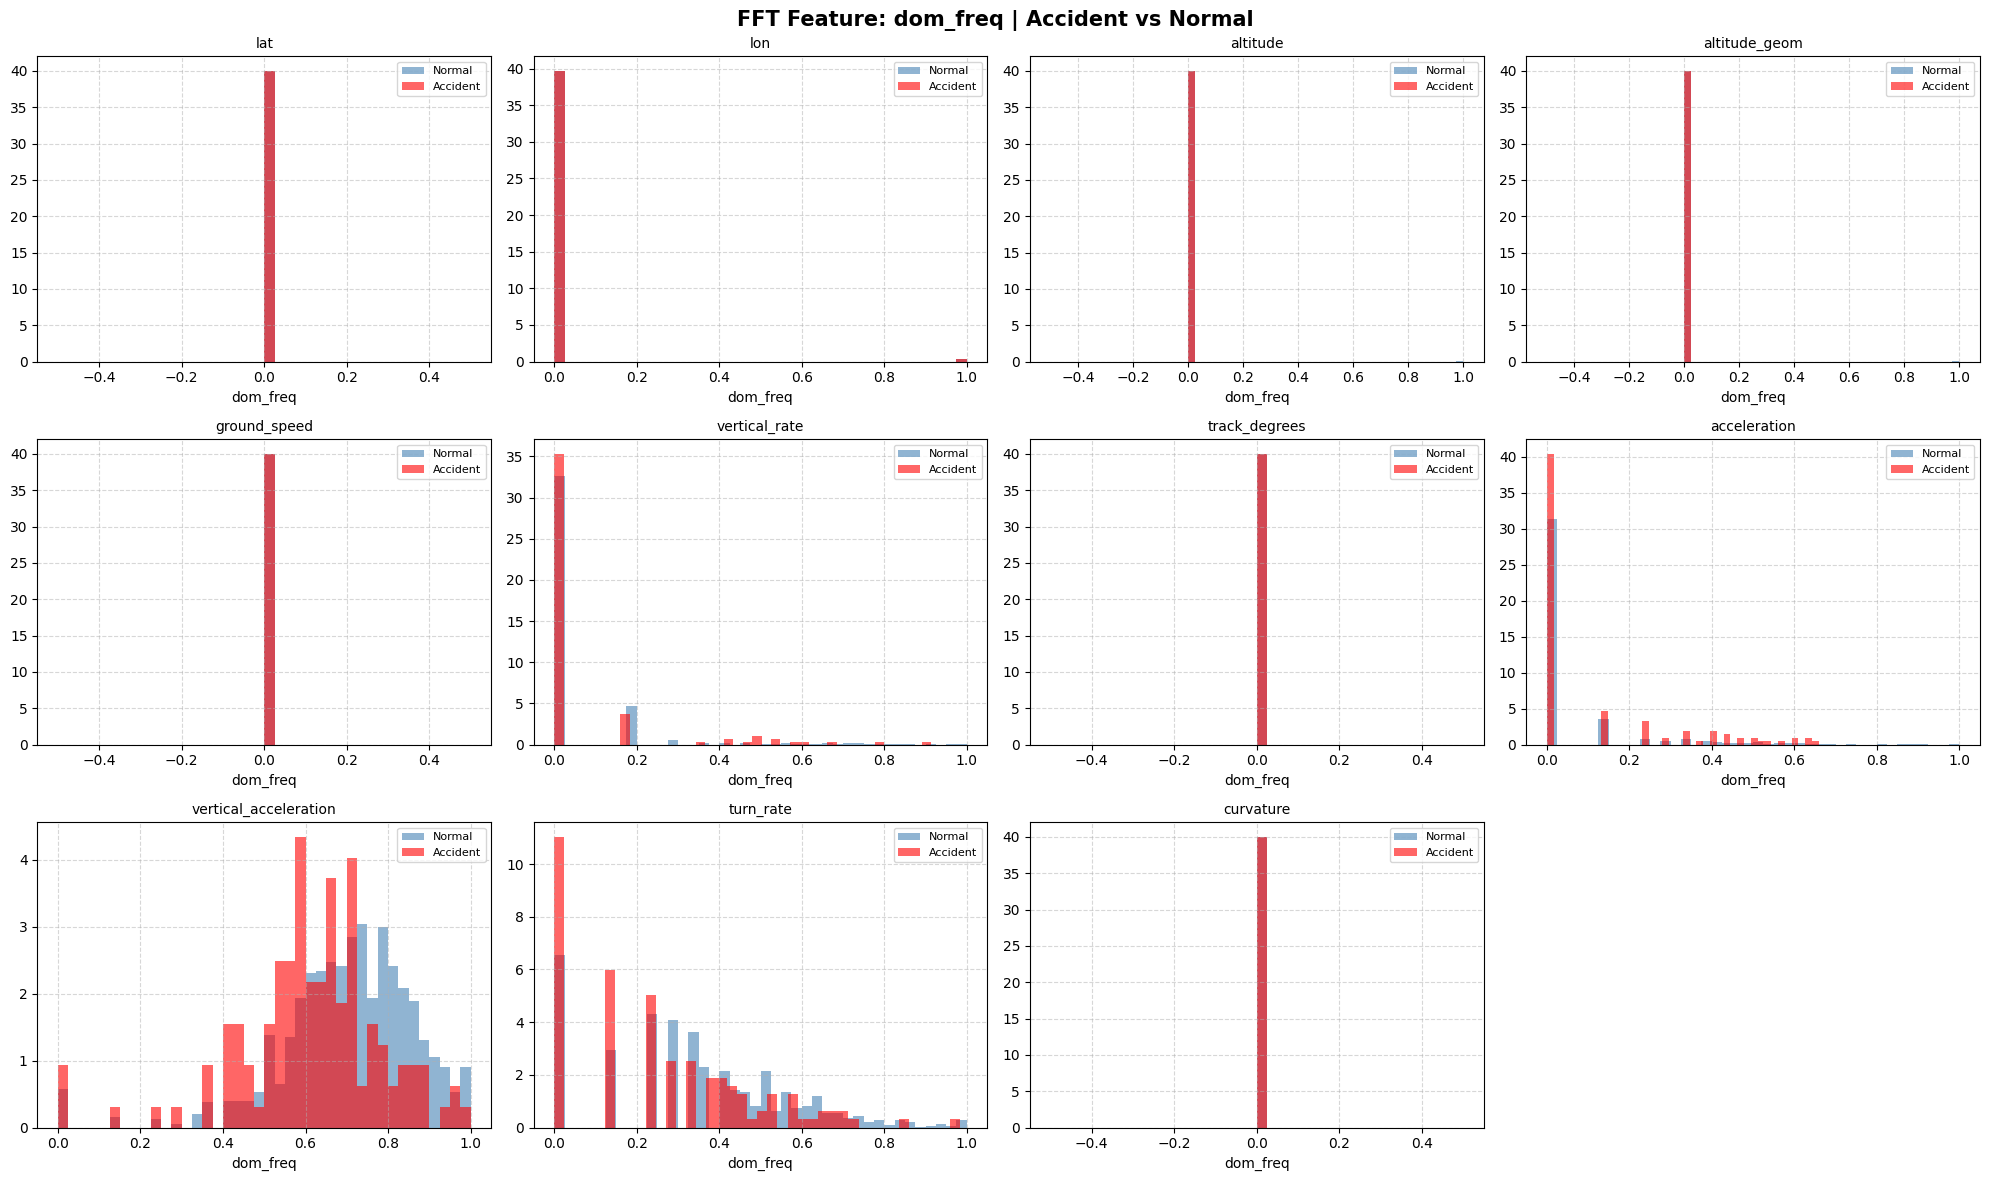

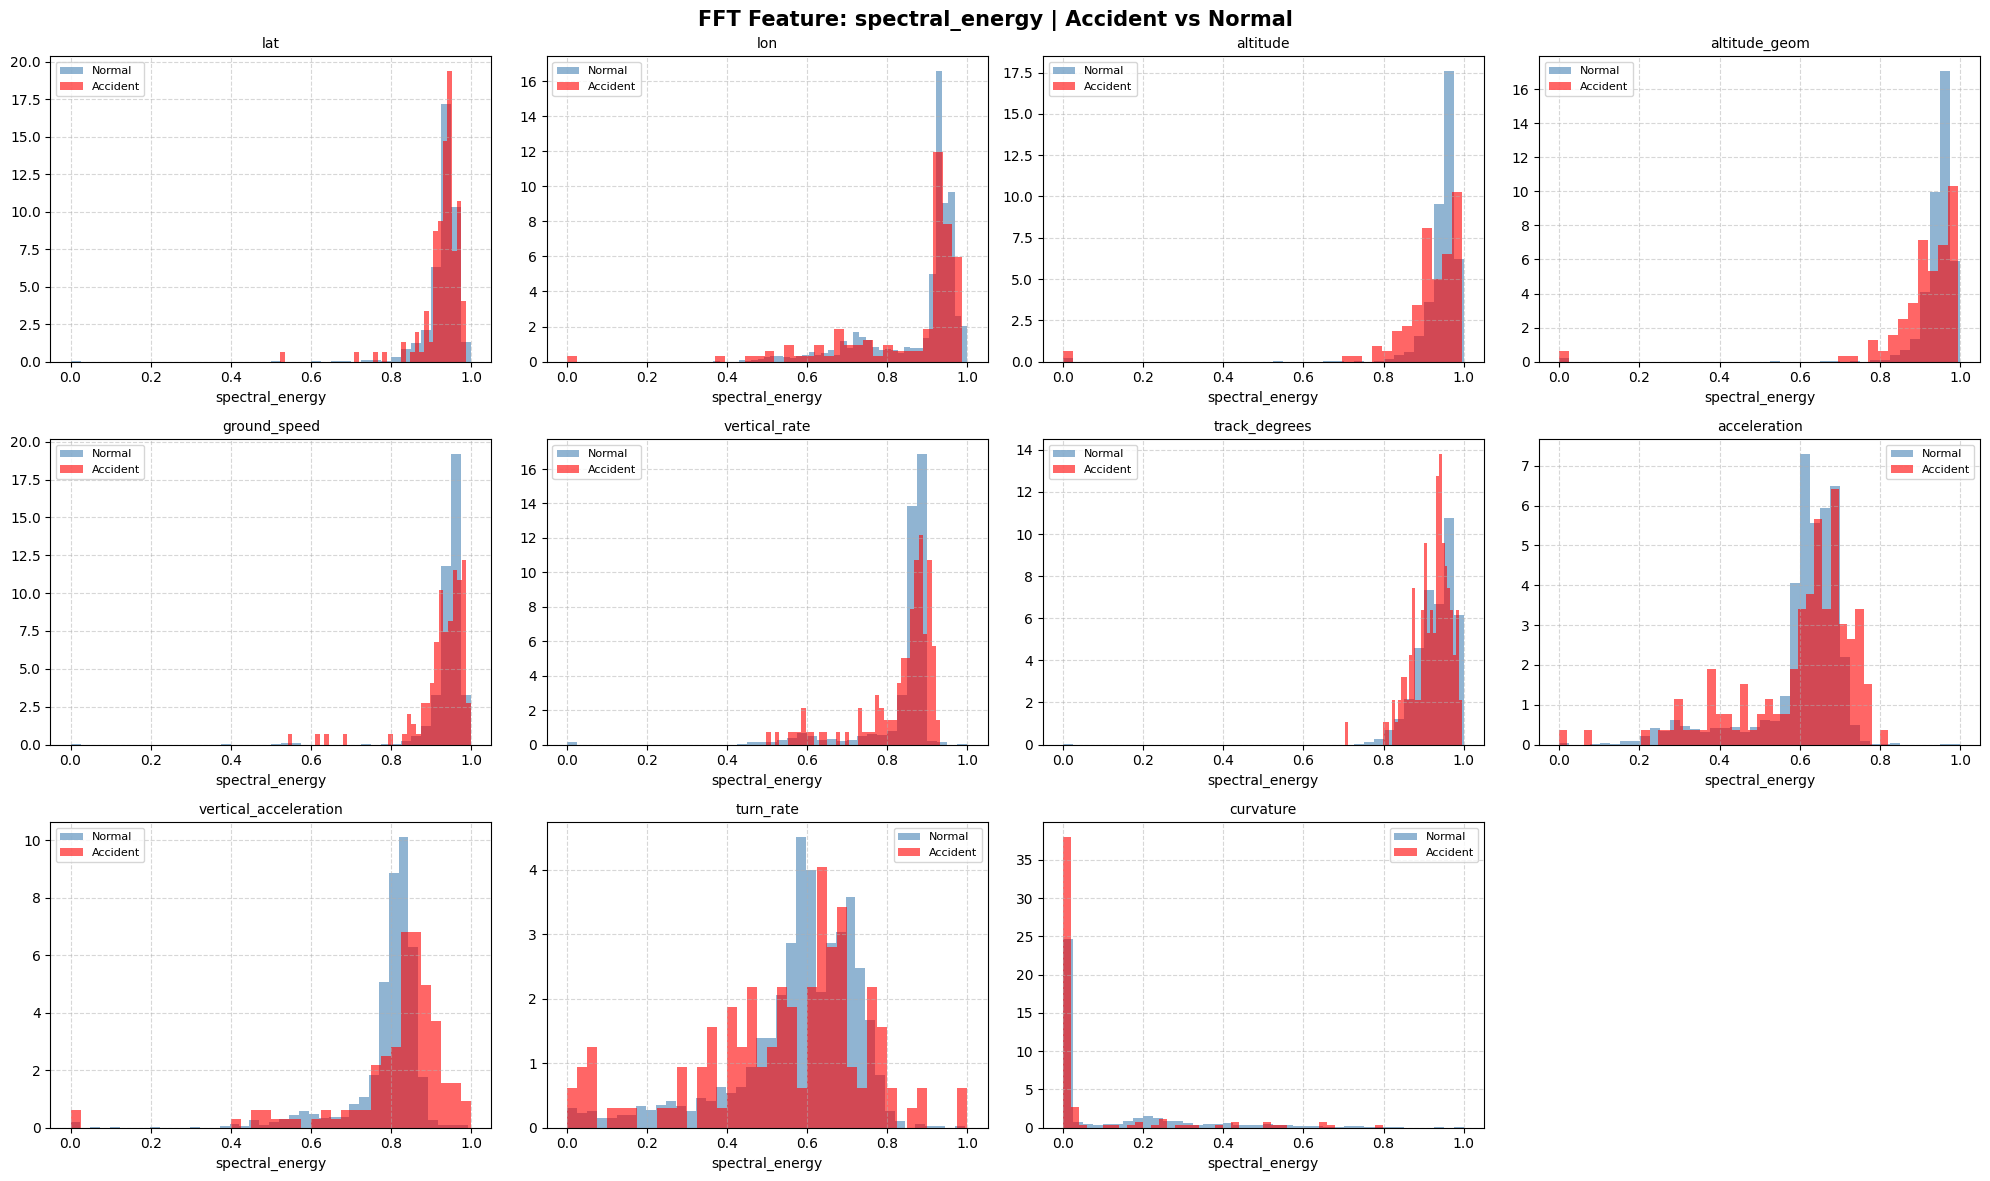

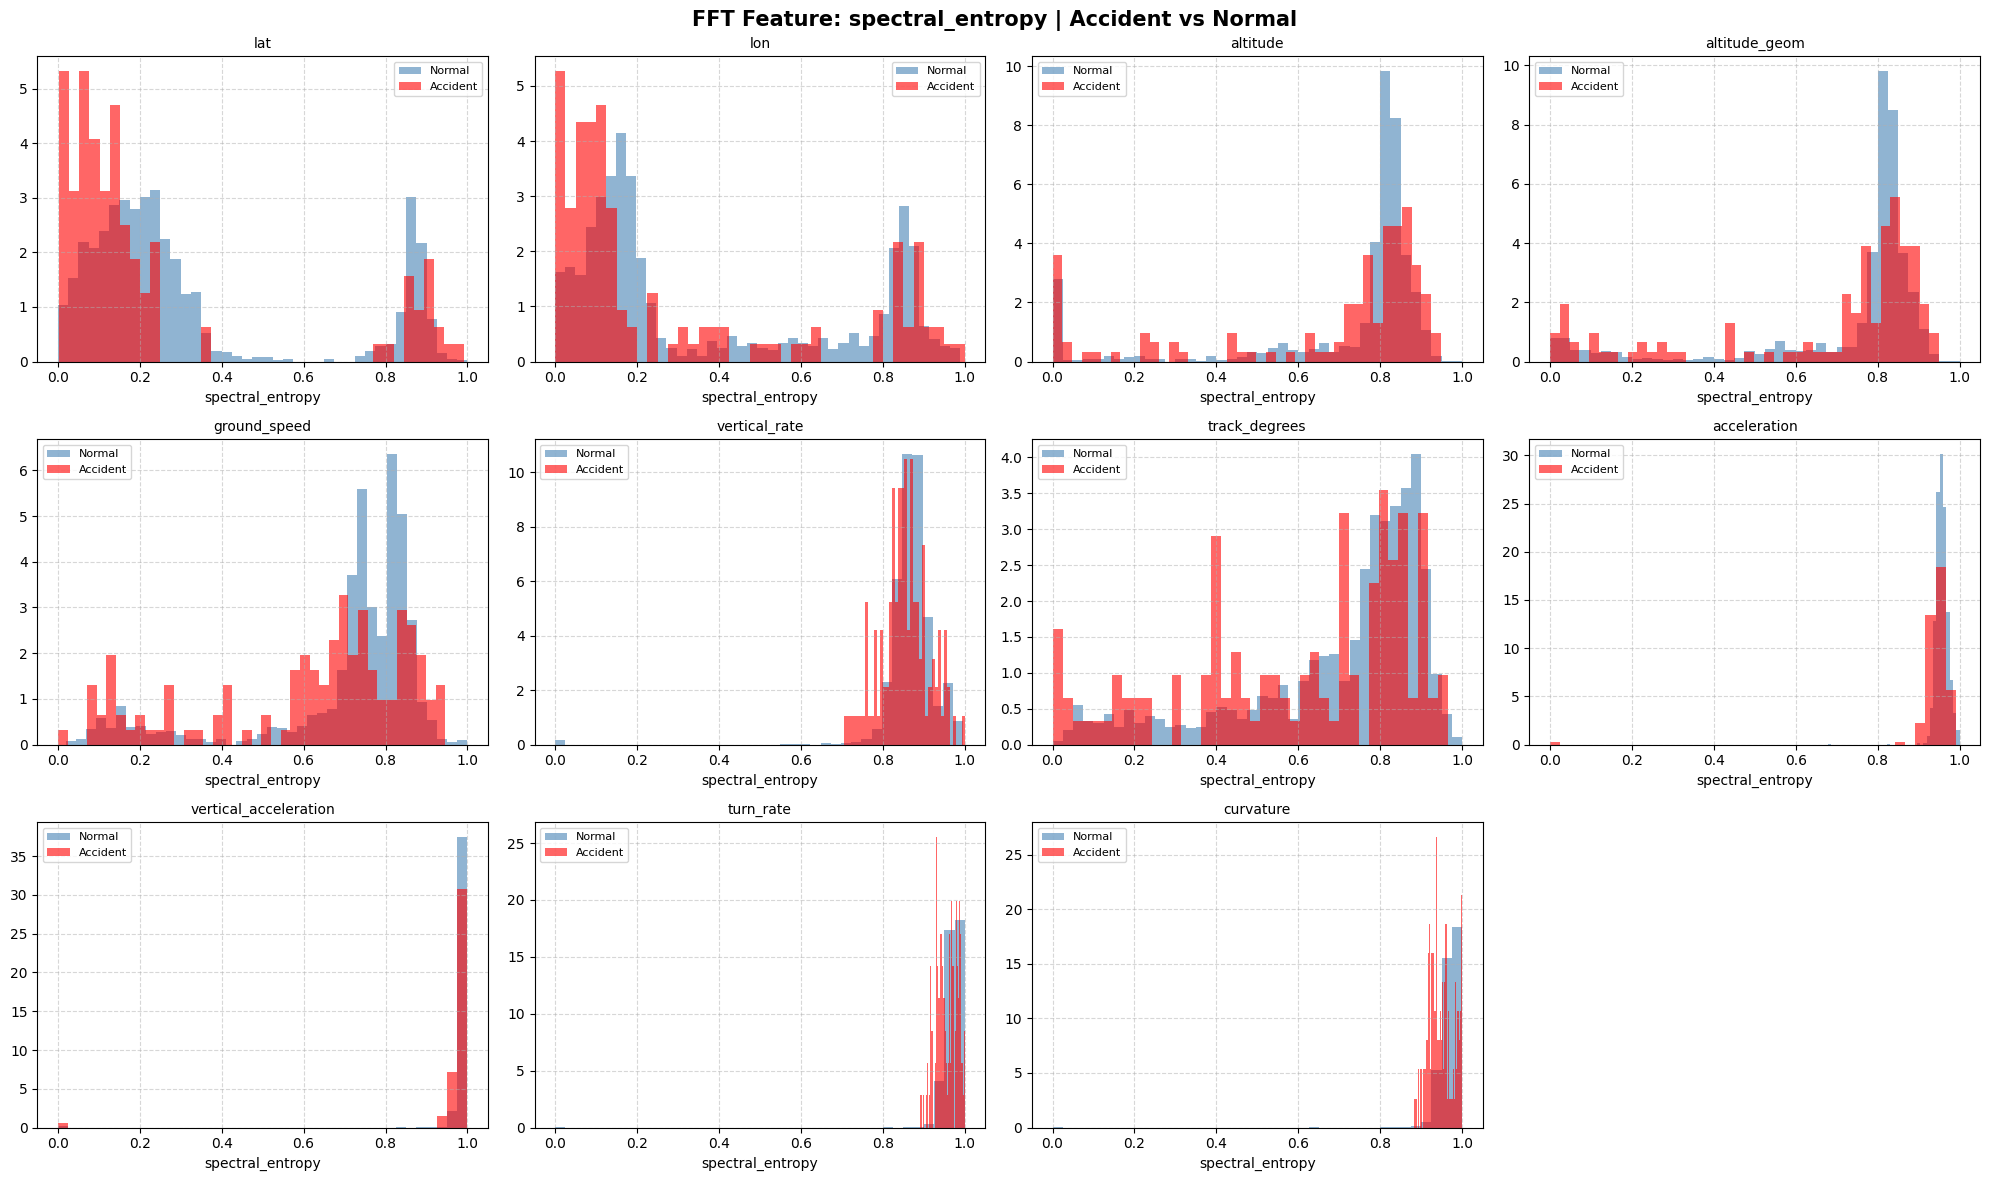

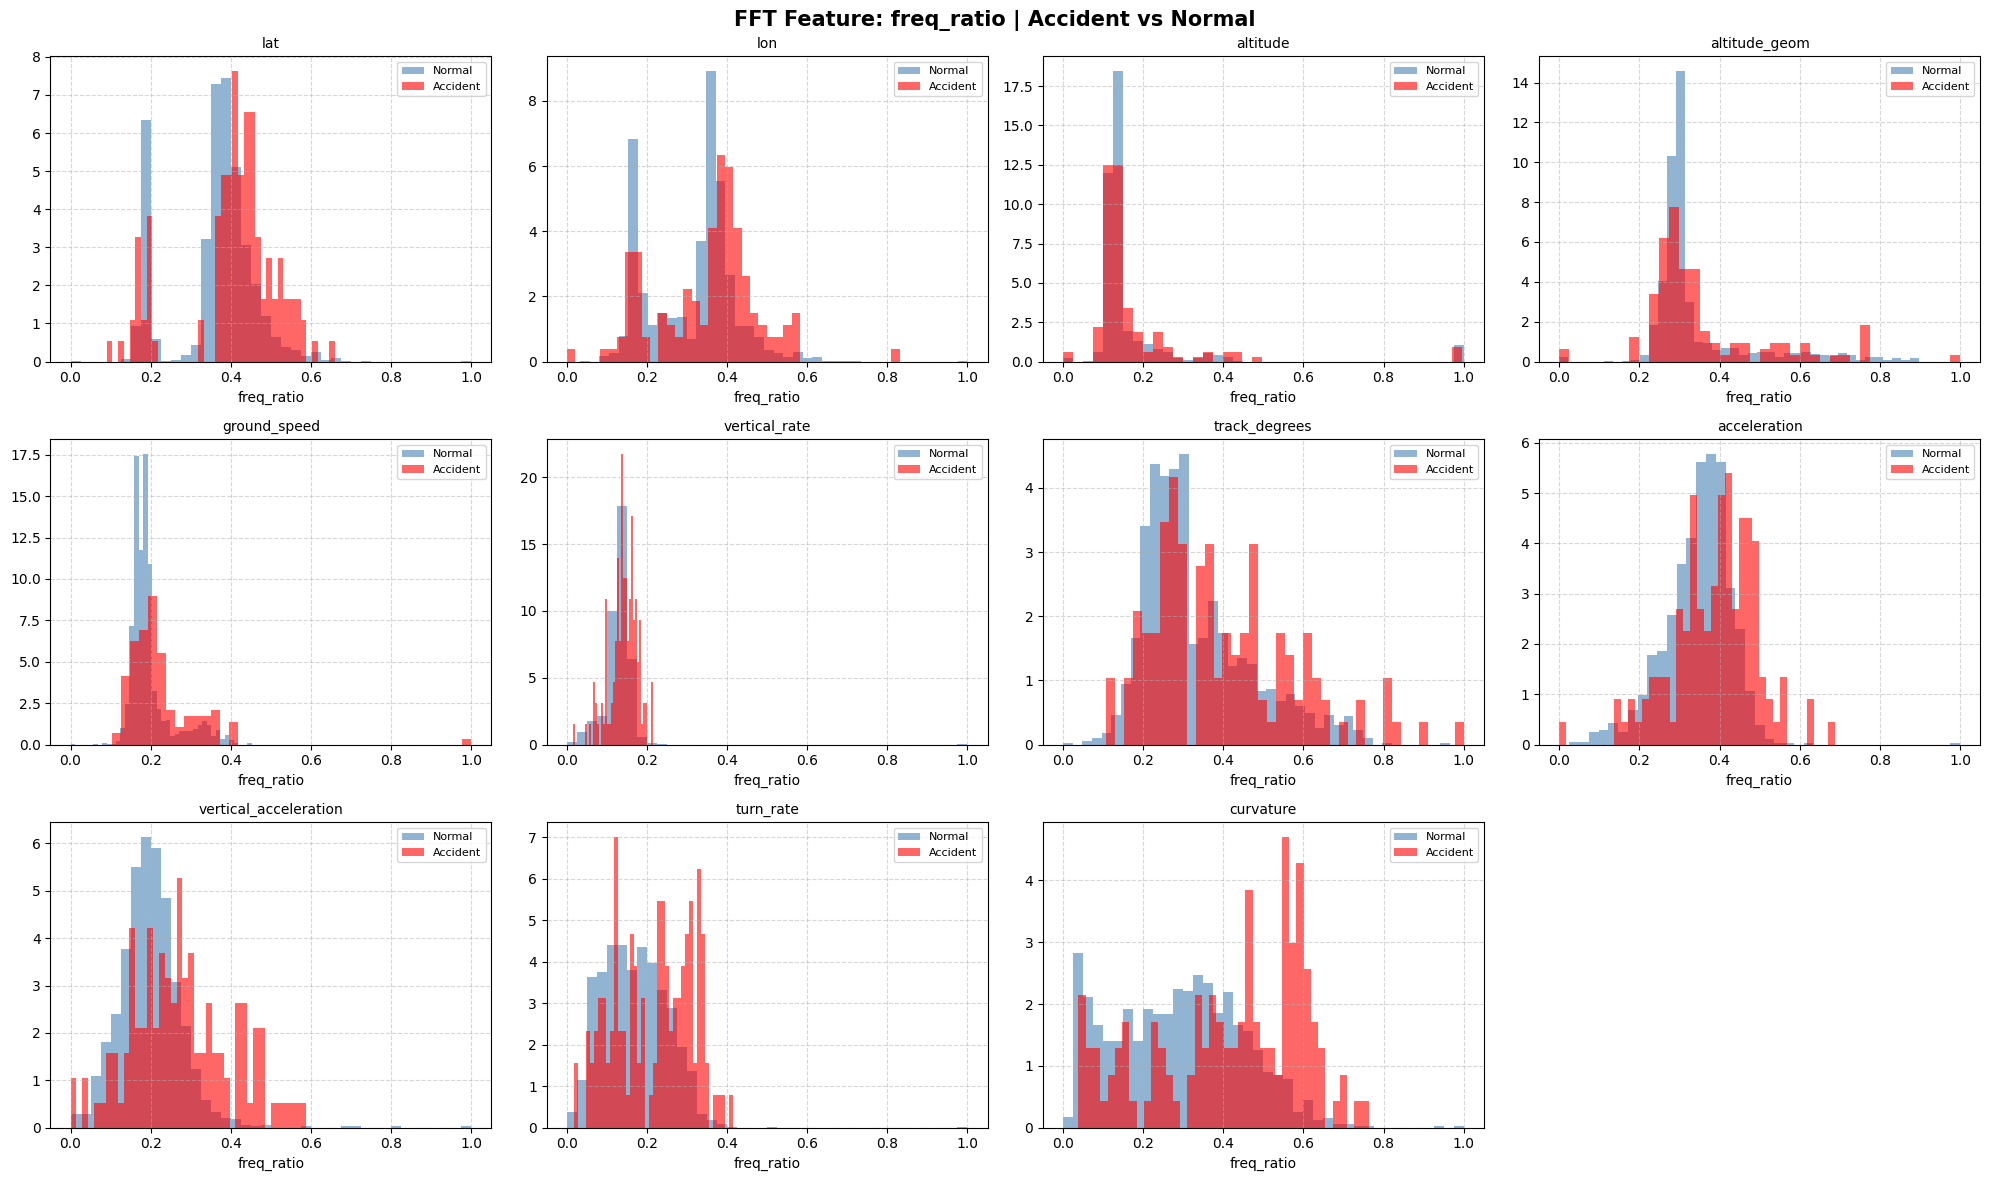

In [29]:
plot_fft_features_by_stat(df_plot, feature_cols)

Now let's compare the distributions of these FFT features for accident and normal flights. 

Looking at the dominant frequencies, we can see that for vertical acceleration and turn rate, accident flights cluster at lower dominant frequencies than normal flights, indicating slower-period oscillations in these signals during abnormal operation.

Looking at the spectral energy, we can see that for vertical_acceleration and turn_rate, accident flights deviate from the sharp concentration observed in normal flights (shown in blue). These visible distributional differences might provide useful patterns for separating accident from normal flights.

For the spectral entropy, the most notable shift appears in ground_speed, where accident flights spread more broadly toward lower entropy values compared to the concentrated normal distribution. Weaker but similar patterns can be observed in altitude, altitude_geom, and track_degrees, suggesting that spectral entropy may complement the other FFT features in distinguishing accident from normal flights.

For the frequency ratio, accident flights show a clear shift toward higher values in curvature, altitude_geom, lat, and vertical_acceleration, indicating that low-frequency components contribute relatively more energy in these signals compared to normal flights.

##### Split & Scale Dataset 

In [30]:
models_cols = X_flat_train.columns.to_list()

In [31]:
X_train, X_val, y_train, y_val = train_test_split(
    X_flat_train, y_train, test_size=0.20, random_state=42, stratify=y_train
)


In [32]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_sc = scaler.transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_flat_test)

In [33]:
X_train_fin = X_train_sc
y_train_fin = y_train
X_val_fin = X_val_sc
X_test_fin = X_test_sc


##### Run KNN Pipeline

Our KNN pipeline integrates feature selection (SelectKBest with mutual information) and a KNN classifier as sequential steps using scikit-learn's Pipeline API. The input consists of aggregated per-flight feature vectors, where each sample represents a single flight encoded by approximately 100 statistical features. 

To address class imbalance, optional oversampling can be enabled directly within each cross-validation training fold, preventing data leakage and ensuring unbiased performance estimates. 

Hyperparameter tuning is performed via GridSearchCV (fast mode) or BayesSearchCV (full mode), optimizing the number of selected features, number of neighbors, distance metric, and weighting strategy jointly.


############################################################
# KNN PIPELINE START
# SMOTE: OFF
############################################################


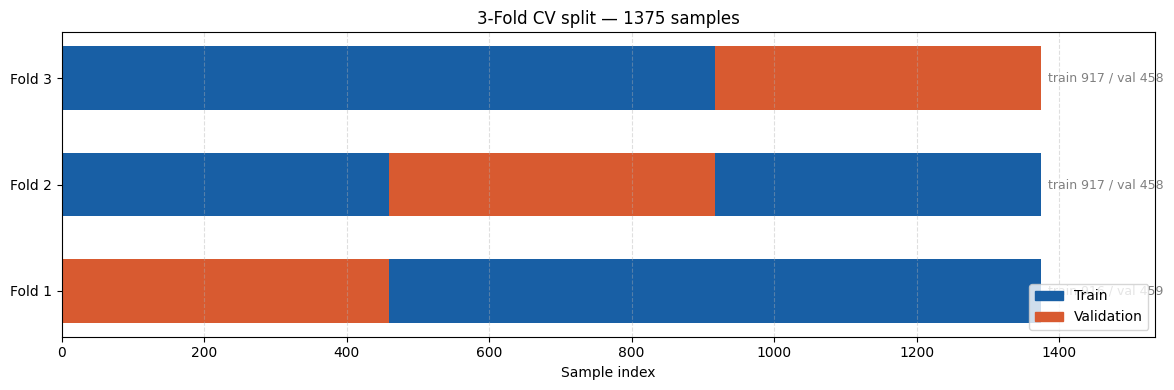


STEP 1/5: HYPERPARAMETER TUNING
  Input shape: X_train=(1375, 132), y_train=(1375,)
  Scoring metric: f1
  Mode: FAST - GridSearchCV
  SMOTE: OFF
  Starting GridSearchCV ...
Fitting 3 folds for each of 1456 candidates, totalling 4368 fits
  Best params : {'feature_selection__k': 60, 'knn__metric': 'manhattan', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
  Best CV score: 0.6386

STEP 2/5: FEATURE IMPORTANCE (Permutation)
  Computing permutation importance ...
  n_repeats=3, n_features=132, X_val shape=(344, 132)
  (each feature will be shuffled and re-scored 3x)


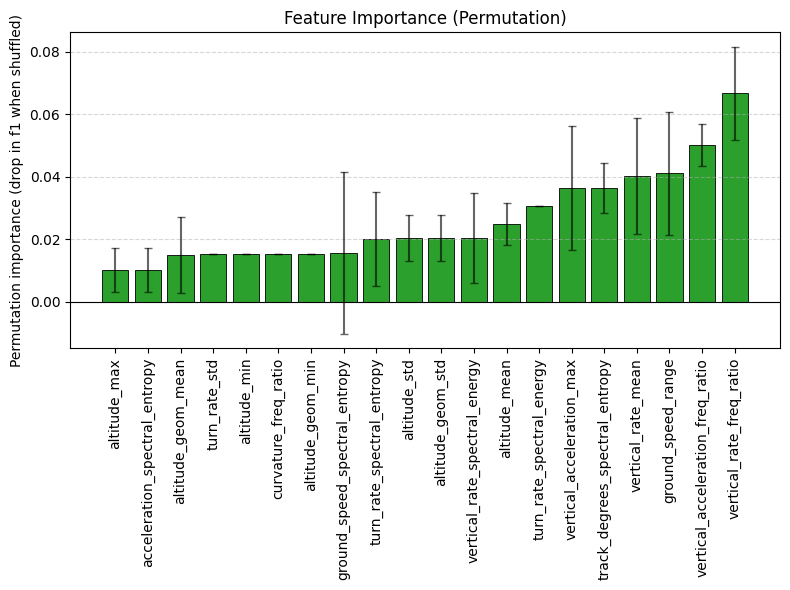


STEP 3/5: TRAIN PERFORMANCE (overfit check)

  Evaluating on TRAIN set (samples=1375, original_features=132, selected_features=60) ...

  ===== TRAIN =====
[[1272    0]
 [   0  103]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1272
         1.0       1.00      1.00      1.00       103

    accuracy                           1.00      1375
   macro avg       1.00      1.00      1.00      1375
weighted avg       1.00      1.00      1.00      1375


STEP 4/5: VALIDATION EVALUATION

  Evaluating on VALIDATION set (samples=344, original_features=132, selected_features=60) ...

  ===== VALIDATION =====
[[315   3]
 [ 11  15]]
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98       318
         1.0       0.83      0.58      0.68        26

    accuracy                           0.96       344
   macro avg       0.90      0.78      0.83       344
weighted avg       0.96      0.96      0

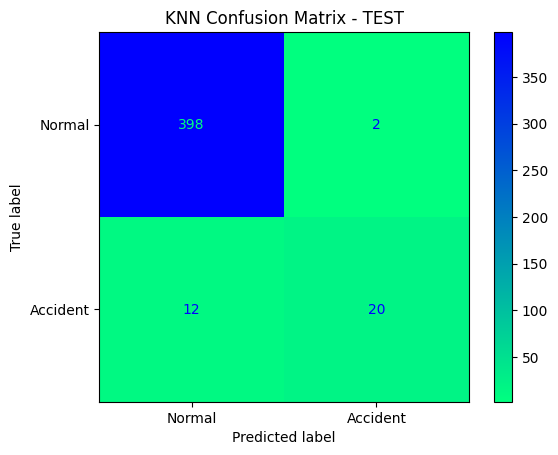


############################################################
# PIPELINE DONE
############################################################


In [34]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
knn, grid = run_knn_pipeline(X_train_fin, y_train_fin, X_val_fin, y_val, X_test_fin, y_test, models_cols, scoring="f1")

In [35]:
print(grid.best_params_)
print(grid.best_score_ )

{'feature_selection__k': 60, 'knn__metric': 'manhattan', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
0.6385983827493261


The KNN pipeline was tuned via 3-fold cross-validated grid search. The best configuration selected 60 features (via mutual information) with n_neighbors=1, Manhattan distance, and uniform weights, reaching a CV F1 of ~ 0.64.

Training performance is perfect (F1 = 1.00 for both classes), which is expected with n_neighbors=1 and not a meaningful indicator of generalization.

On the validation set (n=344), the model achieves 96% accuracy. For the minority "Accident" class, precision is 0.83 and recall is 0.58 (F1 = 0.68), correctly identifying 15 of 26 accidents.

On the test set (n=432), performance is slightly better: 97% accuracy, with precision 0.91 and recall 0.62 for the accident class (F1 = 0.74) — 13 of 32 accidents detected, with only 3 false positives.

The consistent pattern of high precision but moderate recall indicates a conservative model: confident predictions, but a substantial fraction of accidents missed. This is typical for KNN on imbalanced data (≈12:1 ratio). 

Permutation importance highlights vertical_rate_freq_ratio, vertical_acceleration_freq_ratio, and ground_speed_range as the most influential features. 


In [36]:
selector = knn.named_steps['feature_selection']
selected_mask = selector.get_support()
selected_features = np.array(models_cols)[selected_mask]
print(selected_features)

['altitude_mean' 'altitude_geom_mean' 'ground_speed_mean'
 'vertical_rate_mean' 'acceleration_mean' 'vertical_acceleration_mean'
 'turn_rate_mean' 'lat_std' 'lon_std' 'altitude_std' 'altitude_geom_std'
 'ground_speed_std' 'vertical_acceleration_std' 'turn_rate_std'
 'curvature_std' 'altitude_max' 'altitude_geom_max'
 'vertical_acceleration_max' 'curvature_max' 'altitude_min'
 'altitude_geom_min' 'vertical_acceleration_min' 'curvature_min'
 'lat_range' 'lon_range' 'altitude_range' 'altitude_geom_range'
 'ground_speed_range' 'vertical_acceleration_range' 'turn_rate_range'
 'curvature_range' 'curvature_skew' 'altitude_kurtosis'
 'altitude_geom_kurtosis' 'turn_rate_kurtosis' 'curvature_kurtosis'
 'altitude_geom_rms' 'ground_speed_rms' 'vertical_acceleration_rms'
 'altitude_spectral_energy' 'altitude_geom_spectral_energy'
 'ground_speed_spectral_energy' 'vertical_rate_spectral_energy'
 'vertical_acceleration_spectral_energy' 'turn_rate_spectral_energy'
 'curvature_spectral_energy' 'altitude

The 60 selected features capture both time-domain characteristics (magnitude, variability, and extremes) and frequency-domain characteristics (spectral energy, entropy, and dominant frequency content) of the aircraft's motion, reflecting that accident detection benefits from how a flight behaves on average as well as how its dynamics are structured over time.

As a next step, we will retrain the pipeline with SMOTE oversampling to address the class imbalance and aim to improve recall on the minority class.

Before using SMOTE, let's only keep only the features, which were selected by the Feature Importance mechanism


############################################################
# KNN PIPELINE START
# SMOTE: ON
############################################################


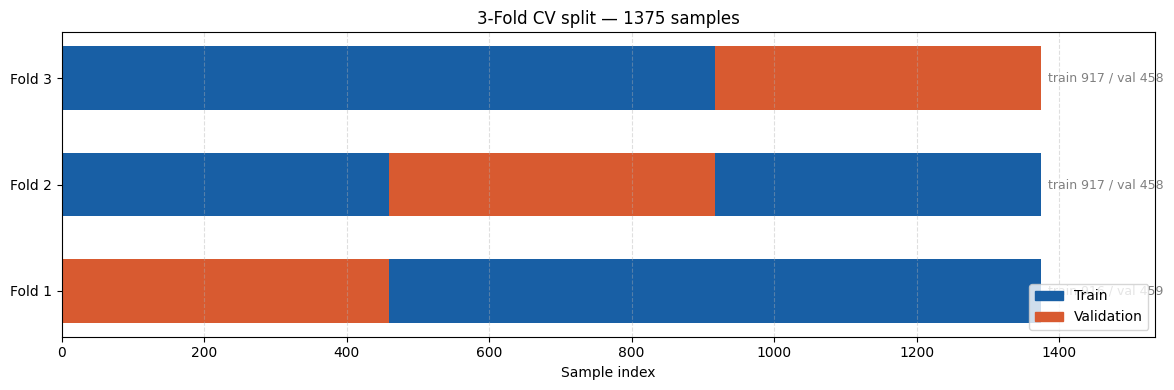


STEP 1/5: HYPERPARAMETER TUNING
  Input shape: X_train=(1375, 132), y_train=(1375,)
  Scoring metric: f1
  Mode: FAST - GridSearchCV
  SMOTE: ON
  Starting GridSearchCV ...
Fitting 3 folds for each of 1456 candidates, totalling 4368 fits
  Best params : {'feature_selection__k': 60, 'knn__metric': 'manhattan', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
  Best CV score: 0.7676

STEP 2/5: FEATURE IMPORTANCE (Permutation)
  Computing permutation importance ...
  n_repeats=3, n_features=132, X_val shape=(344, 132)
  (each feature will be shuffled and re-scored 3x)


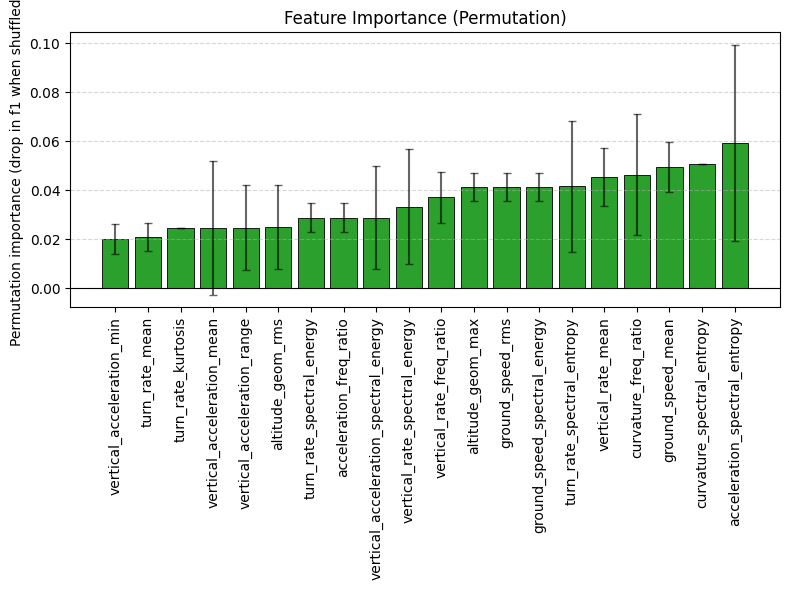


STEP 3/5: TRAIN PERFORMANCE (overfit check)

  Evaluating on TRAIN set (samples=1375, original_features=132, selected_features=60) ...

  ===== TRAIN =====
[[1272    0]
 [   0  103]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1272
         1.0       1.00      1.00      1.00       103

    accuracy                           1.00      1375
   macro avg       1.00      1.00      1.00      1375
weighted avg       1.00      1.00      1.00      1375


STEP 4/5: VALIDATION EVALUATION

  Evaluating on VALIDATION set (samples=344, original_features=132, selected_features=60) ...

  ===== VALIDATION =====
[[309   9]
 [  7  19]]
              precision    recall  f1-score   support

         0.0       0.98      0.97      0.97       318
         1.0       0.68      0.73      0.70        26

    accuracy                           0.95       344
   macro avg       0.83      0.85      0.84       344
weighted avg       0.96      0.95      0

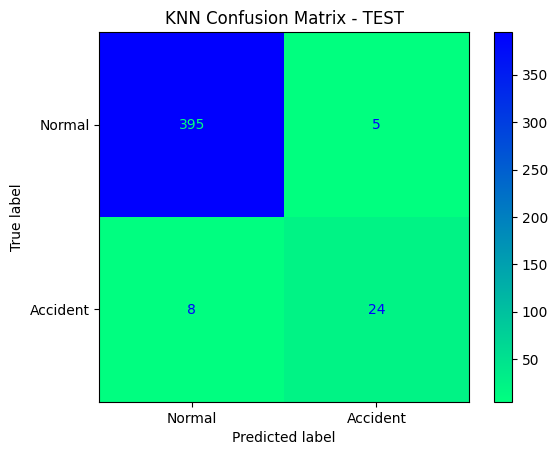


############################################################
# PIPELINE DONE
############################################################


In [37]:
knn, grid = run_knn_pipeline(X_train_fin, y_train_fin, X_val_fin, y_val, X_test_fin, y_test, models_cols, scoring="f1", use_smote = True)


In [38]:
print(grid.best_params_)
print(grid.best_score_ )

{'feature_selection__k': 60, 'knn__metric': 'manhattan', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
0.7675531155696924


Applying SMOTE within the cross-validation pipeline yields a notably improved CV F1 of 0.7676 (vs. 0.6386 without SMOTE), with the same best configuration selected: 60 features, n_neighbors=1, Manhattan distance.

On the validation set, recall for the "Accident" class improves from 0.58 to 0.73, while precision drops slightly from 0.83 to 0.68, a favorable trade-off given that missing an accident is costlier than a false alarm. Overall accuracy remains at 95%.

On the test set, the improvement is consistent: recall rises from 0.62 to 0.75 and precision from 0.91 to 0.83, pushing the accident-class F1 from 0.74 to 0.79. The number of missed accidents drops from 12 to 8.

SMOTE effectively addresses the class imbalance by generating synthetic minority samples during training, allowing the model to better capture the decision boundary around the accident class, without any change to the model architecture or feature selection strategy.

We are quite happy with the results, as our dataset was highly imbalanced (≈12:1) and inherently difficult to model. Achieving an accident-class F1 of 0.79 on the test set, with a recall of 0.75, represents a solid baseline given these constraints. For this reason, we consider the KNN pipeline a satisfactory solution and will not pursue further tuning or additional models at this stage. That said, more expressive models such as XGBoost or sequence-based architectures like LSTM could potentially improve performance further, particularly by capturing temporal dependencies in the flight data or better handling the non-linear decision boundary between normal and accident trajectories.


We will now proceed with the full pipeline using BayesSearchCV (100 iterations, 10-fold cross-validation) instead of the fast grid search. This allows us to explore a significantly larger hyperparameter space including feature count, number of neighbors, distance metric, and weighting scheme, while the 10-fold CV potentially reduces variance in the score estimates and provides a more reliable selection of the optimal configuration.


############################################################
# KNN PIPELINE START
# SMOTE: ON
############################################################


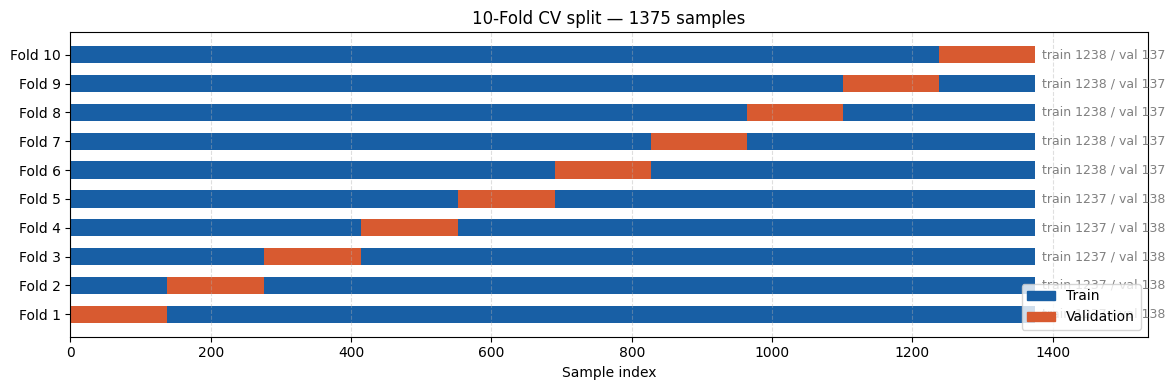


STEP 1/5: HYPERPARAMETER TUNING
  Input shape: X_train=(1375, 132), y_train=(1375,)
  Scoring metric: f1
  Mode: FULL - BayesSearchCV
  SMOTE: ON
  Best params : OrderedDict({'feature_selection__k': 104, 'knn__metric': 'manhattan', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'})
  Best CV score: 0.7736

STEP 2/5: FEATURE IMPORTANCE (Permutation)
  Computing permutation importance ...
  n_repeats=10, n_features=132, X_val shape=(344, 132)
  (each feature will be shuffled and re-scored 10x)


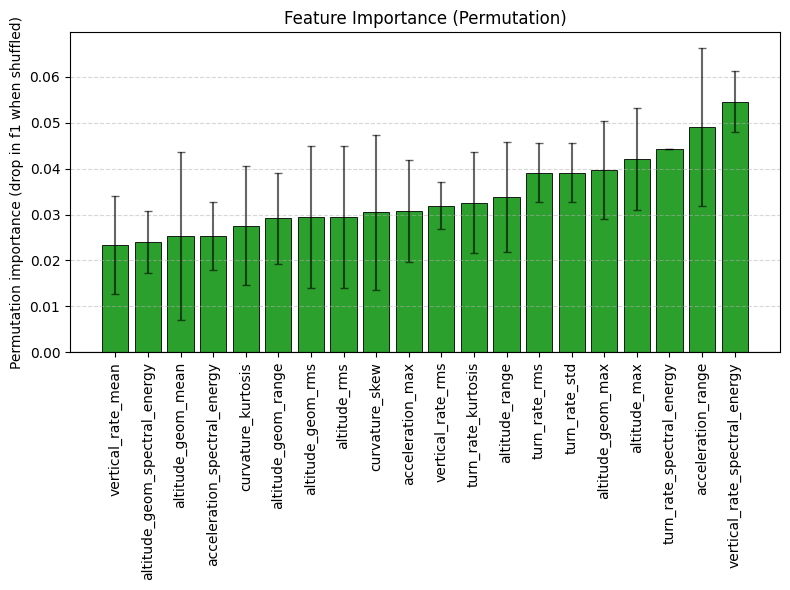


STEP 3/5: TRAIN PERFORMANCE (overfit check)

  Evaluating on TRAIN set (samples=1375, original_features=132, selected_features=104) ...

  ===== TRAIN =====
[[1272    0]
 [   0  103]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1272
         1.0       1.00      1.00      1.00       103

    accuracy                           1.00      1375
   macro avg       1.00      1.00      1.00      1375
weighted avg       1.00      1.00      1.00      1375


STEP 4/5: VALIDATION EVALUATION

  Evaluating on VALIDATION set (samples=344, original_features=132, selected_features=104) ...

  ===== VALIDATION =====
[[308  10]
 [  4  22]]
              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98       318
         1.0       0.69      0.85      0.76        26

    accuracy                           0.96       344
   macro avg       0.84      0.91      0.87       344
weighted avg       0.96      0.96     

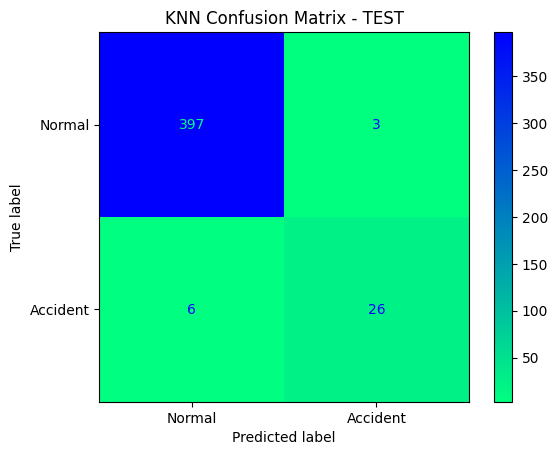


############################################################
# PIPELINE DONE
############################################################


In [39]:
knn, grid = run_knn_pipeline(X_train_fin, y_train_fin, X_val_fin, y_val, X_test_fin, y_test, models_cols, scoring="f1", use_smote = True, fast=False)


In [40]:
print(grid.best_params_)
print(grid.best_score_ )

OrderedDict({'feature_selection__k': 104, 'knn__metric': 'manhattan', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'})
0.7735611509009678
